## AI-Generated Financial Misinformation Generation



    Motivation for Synthetic Data Generation

    Real-world AI-generated financial misinformation datasets are limited because
    large-scale labelled examples are difficult to obtain. Therefore, synthetic misinformation is generated from authentic financial
    news articles using controlled prompting.
    
    The generated samples simulate realistic manipulation scenarios and are used
    to evaluate detection model robustness.





This notebook is to generate synthetic financial misinformation from real financial news.

The original financial news articles are transformed into three categories:

1. Bullish misinformation:
   - exaggerates positive outcomes
   - increases perceived company performance

2. Bearish misinformation:
   - exaggerates risks and negative implications

3. Neutral AI rewrite:
   - preserves factual information while changing writing style

Used for:
- AI-generated misinformation detection
- Model robustness evaluation

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import os
import json
import time

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from openai import OpenAI

## Load API Key

In [ ]:
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

print("OpenAI API connected")

OpenAI API connected


## Load Financial News Dataset

The source dataset consists of cleaned financial news articles
prepared during the data cleaning phase.

Articles were filtered based on minimum text length to ensure
sufficient context for LLM transformation.

The selected articles contain financial topics such as:

- company performance
- earnings
- market movements
- business events

In [ ]:
# Paths
PROCESSED_PATH = "data/processed"

os.makedirs(PROCESSED_PATH, exist_ok=True)

financial_news = pd.read_csv(
    f"{PROCESSED_PATH}/financial_news_clean.csv"
)

## Dataset Inspection

In [ ]:
financial_news.head()

,company_ticker,publication_date,title,article_text,source,word_count
0,AAPL,2026-06-22,Memory's price surge threatens Apple's 'magic ...,Wall Street Journal technology reporter Rolfe ...,Yahoo Finance Video,28
1,AAPL,2026-06-23,"Ranking the ""Magnificent Seven"" From Most to L...","Among Nvidia, Alphabet, Apple, Microsoft, Amaz...",Motley Fool,21
2,AAPL,2026-06-23,Jim Cramer Discusses President Trump’s Big Ann...,We recently published Jim Cramer Discussed Exp...,Insider Monkey,56
3,AAPL,2026-06-23,Does Elon Musk represent a new form of capital...,"LONDON, June 23 (Reuters Breakingviews) - Foll...",Reuters,29
4,AAPL,2026-06-22,What Dell Stock's AI Order Book Revealed Befor...,"Before the stock more than tripled, the compan...",Trefis,25


In [ ]:
print("Shape:", financial_news.shape)

Shape: (201, 6)


In [ ]:
financial_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   company_ticker    201 non-null    object
 1   publication_date  201 non-null    object
 2   title             201 non-null    object
 3   article_text      201 non-null    object
 4   source            201 non-null    object
 5   word_count        201 non-null    int64 
dtypes: int64(1), object(5)
memory usage: 9.6+ KB


In [ ]:
# Article Length Analysis
financial_news["word_count"] = (
    financial_news["article_text"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)

financial_news["word_count"].describe()

,word_count
count,201.000000
mean,48.228856
std,24.594051
min,20.000000
25%,27.000000
50%,48.000000
75%,67.000000
max,225.000000


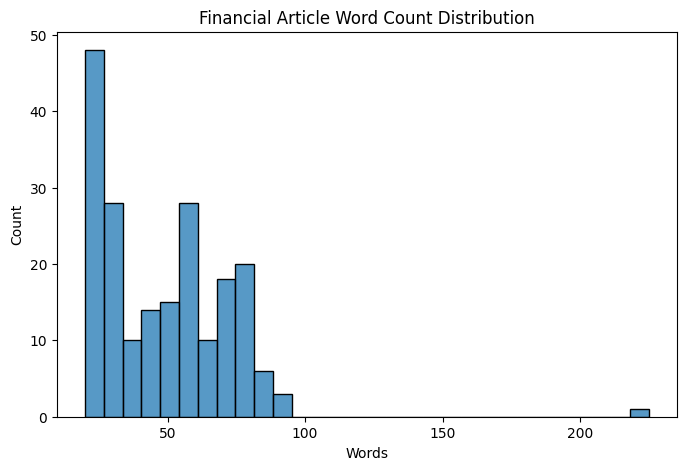

In [ ]:
# Plot Word Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    financial_news["word_count"],
    bins=30
)
plt.title("Financial Article Word Count Distribution")
plt.xlabel("Words")
plt.show()

In [ ]:
# Select Source Articles
source_articles = financial_news[
    financial_news["word_count"] >= 40
].copy()

print(
    "Available articles:",
    len(source_articles)
)

Available articles: 116


In [ ]:
# Sample Articles
source_articles = source_articles.sample(
    n=min(
        100,
        len(source_articles)
    ),
    random_state=42
)

source_articles = (
    source_articles
    .reset_index(drop=True)
)

source_articles.shape

(100, 6)

    Ethical Considerations

    Synthetic misinformation is generated only for research and evaluation
    purposes.

    The generated content is not intended for publication or financial advice.
    The objective is to improve detection systems and understand model
    limitations against manipulated financial information.

## Generation Function

Each real article was transformed into three versions:

| Type | Purpose |
|------|---------|
| Bullish | Simulates exaggerated positive misinformation |
| Bearish | Simulates exaggerated negative misinformation |
| Neutral | Simulates AI-written but fact-preserving text |

The original article information was preserved to allow comparison
between real and generated content.

In [ ]:
# Define Prompts
prompts = {

"bullish":

"""
Transform this financial news article into a misleading
bullish financial article.

Requirements:
- Preserve the original company and topic
- Exaggerate positive outcomes
- Overstate growth potential or investor expectations
- Make the article sound like realistic financial journalism
- Keep financial terminology
- Do not create completely unrelated events
- Avoid obvious fake wording

Article:
""",


"bearish":

"""
Transform this financial news article into misleading
negative financial news.

Requirements:
- Preserve the original company and topic
- Exaggerate risks, losses, or concerns
- Create investor uncertainty or fear
- Make the article sound like realistic financial journalism
- Keep financial terminology
- Do not create completely unrelated events
- Avoid obvious fake wording

Article:
""",


"neutral":

"""
Rewrite this financial news article using AI.

Requirements:
- Preserve factual meaning
- Change wording and sentence structure
- Keep company and financial information
- Make it look AI-generated
- Do not add false claims

Article:
"""

}

**Generation Model Information**

LLM used: GPT-4.1-mini

Generation temperature: 0.8

Prompt-based controlled generation was selected instead of unrestricted
generation to maintain:

- company consistency
- financial topic relevance
- realistic misinformation patterns
- reproducibility

In [ ]:
# Generation Function
def generate_article(
    article,
    style
):

    response = client.chat.completions.create(

        model="gpt-4.1-mini",

        messages=[
            {
                "role":"user",
                "content":
                prompts[style] + article
            }
        ],

        temperature=0.8
    )


    return (
        response
        .choices[0]
        .message
        .content
    )

In [ ]:
# Test One Generation
test_article = (
    source_articles
    .iloc[0]
    ["article_text"]
)

result = generate_article(
    test_article,
    "bullish"
)

print(result)

McDonald's is set to reignite its legendary appeal by bringing back its iconic Fried Apple Pie starting June 22, a move widely anticipated to spark unprecedented consumer excitement and significantly boost sales. Originally removed from U.S. menus in 1992, the Fried Apple Pie has become a cult favorite, with relentless customer demand driving McDonald's to reintroduce this classic treat as part of a powerful nostalgia-driven marketing campaign. Industry analysts predict this strategic relaunch will not only skyrocket in-store traffic but also catalyze a sustained surge in quarterly revenues throughout the year.

For investors keeping a close eye on McDonald's, trading under the NYSE ticker MCD, this development adds a robust consumer-centric growth catalyst to an already strong portfolio. The stock, which last closed at $287.93, has already demonstrated impressive resilience, soaring by over 40% in the past five years. With the Fried Apple Pie's comeback expected to further enhance bra

In [ ]:
print(len(result.split()))

196


**LLM Generation Process**

For each selected financial article:

1. Provide the article text as input
2. Apply a predefined transformation prompt
3. Generate a synthetic article
4. Store generation metadata

Metadata stored:

- original article
- generated article
- generation type
- company information
- source type
- classification label

In [ ]:
# Generate Synthetic Dataset
synthetic_records = []

for index,row in tqdm(
    source_articles.iterrows(),
    total=len(source_articles)
):

    original = row["article_text"]

    for style in [
        "bullish",
        "bearish",
        "neutral"
    ]:


        generated = generate_article(
            original,
            style
        )

        synthetic_records.append(
            {

            "original_article":
            original,

            "generated_article":
            generated,

            "prompt_type":
            style,

            "company":
            row.get(
                "company_ticker",
                "unknown"
            ),

            "source_type":
            "AI_generated",

            "label":
            1
            }
        )

        time.sleep(0.5)

100%|██████████| 100/100 [22:03<00:00, 13.23s/it]


In [ ]:
# Create DataFrame
synthetic_df = pd.DataFrame(
    synthetic_records
)

synthetic_df.head()

,original_article,generated_article,prompt_type,company,source_type,label
0,McDonald's is bringing back its Fried Apple Pi...,McDonald's is set to ignite consumer enthusias...,bullish,MCD,AI_generated,1
1,McDonald's is bringing back its Fried Apple Pi...,McDonald's is reintroducing its Fried Apple Pi...,bearish,MCD,AI_generated,1
2,McDonald's is bringing back its Fried Apple Pi...,McDonald's is reintroducing its Fried Apple Pi...,neutral,MCD,AI_generated,1
3,We recently published Jim Cramer Discussed Exp...,In a recent analysis highlighted by Jim Cramer...,bullish,MSFT,AI_generated,1
4,We recently published Jim Cramer Discussed Exp...,Recent analysis highlights growing concerns ar...,bearish,MSFT,AI_generated,1


In [ ]:
synthetic_df.shape

(300, 6)

The generated articles are checked for:

- sufficient text length
- correct generation category
- preservation of company context
- removal of failed generations

This reduces low-quality synthetic examples before model training.

## Create Real News Dataset

In [ ]:
real_news = source_articles[
    [
    "article_text"
    ]
].copy()

real_news = real_news.rename(
    columns={
        "article_text":
        "generated_article"
    }
)

real_news["original_article"] = (
    real_news["generated_article"]
)


real_news["prompt_type"] = (
    "original"
)

real_news["source_type"] = (
    "real"
)

real_news["label"] = 0

The final classification dataset combines:

Real financial news:
- Label = 0

AI-generated financial content:
- Label = 1

The final dataset can be used for supervised learning tasks
to distinguish human-written and AI-generated financial text.

Neutral AI rewrites are included as AI-generated text examples because the
objective is to detect AI-generated financial content, while bullish and
bearish variants specifically simulate misinformation.

In [ ]:
# Combine Real + AI
final_dataset = pd.concat(
    [
        real_news,
        synthetic_df
    ],
    ignore_index=True
)

final_dataset.shape

(400, 6)

In [ ]:
# Add Length Feature
final_dataset["length"] = (
    final_dataset["generated_article"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)

final_dataset["length"].describe()

,length
count,400.00000
mean,140.74250
std,79.93996
min,30.00000
25%,68.00000
50%,111.50000
75%,216.25000
max,363.00000


In [ ]:
# Remove Bad Generations
final_dataset = final_dataset[
    final_dataset["length"] >= 30
]

final_dataset.shape

(400, 7)

In [ ]:
# Distribution Check
print(
    final_dataset["label"]
    .value_counts()
)

print(
    final_dataset["prompt_type"]
    .value_counts()
)

label
1    300
0    100
Name: count, dtype: int64
prompt_type
original    100
bullish     100
bearish     100
neutral     100
Name: count, dtype: int64


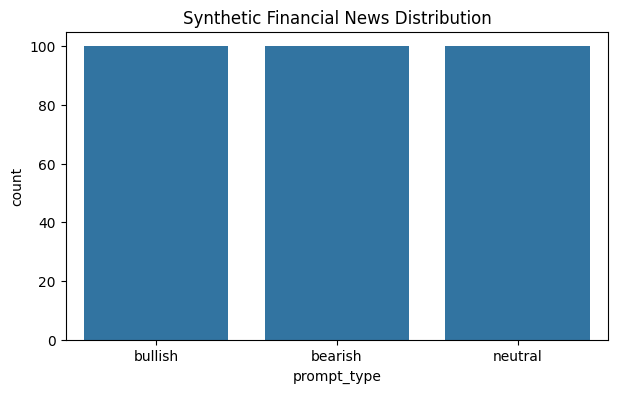

In [ ]:
# Plot Synthetic Types
plt.figure(figsize=(7,4))

sns.countplot(
    data=synthetic_df,
    x="prompt_type"
)

plt.title(
    "Synthetic Financial News Distribution"
)

plt.show()

In [ ]:
# View Samples
final_dataset.sample(
    10
)[
[
"generated_article",
"label",
"prompt_type"
]
]

,generated_article,label,prompt_type
342,The S&P 500 (^GSPC) features some of the large...,1,neutral
210,(Bloomberg) — Gold prices declined sharply tow...,1,neutral
358,Costco Wholesale (NasdaqGS:COST) is set to rev...,1,bullish
161,Chevron Corporation (NYSE: CVX) is raising con...,1,bearish
4,Stock futures were tumbling on Tuesday as inve...,0,original
186,As consumer demand for organic foods and fresh...,1,neutral
346,Scott Melker highlights a groundbreaking move ...,1,bullish
334,With a short interest of just 1.21% of shares ...,1,bullish
195,Shares of Block Inc (NYSE: SQ) surged 17% duri...,1,neutral
380,"Atlas Energy Solutions Inc. (NYSE:AESI), despi...",1,bearish


In [ ]:
# Final Summary
print("Final Dataset")

print(final_dataset.shape)

print(final_dataset["source_type"].value_counts())

Final Dataset
(400, 7)
source_type
AI_generated    300
real            100
Name: count, dtype: int64


In [ ]:
# Save Final Dataset
final_dataset.to_csv(
    f"{PROCESSED_PATH}/synthetic_financial_news.csv",
    index=False
)

print(
    "Saved successfully"
)

Saved successfully


This notebook created a controlled synthetic financial misinformation dataset
by transforming real financial articles.

Generated:

- Original financial articles: 100
- AI-generated articles: 300

AI generation categories:

- Bullish misinformation: 100
- Bearish misinformation: 100
- Neutral AI rewrite: 100

Synthetic data generation was performed using GPT-4.1-mini. The generated dataset is provided in the processed data directory to ensure reproducibility without requiring external API access.